In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [26]:
# Load weighting potential (computed for the center pixel)
npz_path = '../store/potential/weight3d.npz'
weight3d = np.load(npz_path)['weight3d']
print(f'weight3d shape (x, y, z): {weight3d.shape}')
print(f'dtype: {weight3d.dtype},  min: {weight3d.min():.4f},  max: {weight3d.max():.4f}')

weight3d shape (x, y, z): (396, 396, 1500)
dtype: float64,  min: 0.0000,  max: 1.0000


In [27]:
# ── Physical parameters ───────────────────────────────────────────────────────
step_mm        = 0.1    # mm per voxel
pixel_size_mm  = 3.5
pixel_gap_mm   = 0.9
pixel_pitch_mm = pixel_size_mm + pixel_gap_mm   # 4.4 mm
n_pixels       = 9

# z layout (physical mm = z_index * step_mm):
#   z = 0 mm       : PCB bottom
#   z = 10 mm      : pixel plane  (z_index = 100)
#   z = 150 mm     : cathode      (z_index = 1499)
iz_pixel  = 100    # pixel plane voxel index
iz_pcb    = 0      # PCB bottom voxel index

nx, ny, nz = weight3d.shape

# Physical coordinate arrays (mm), no centering or flipping
x_mm = np.arange(nx) * step_mm          # 0 .. 39.5 mm
z_mm = np.arange(nz) * step_mm          # 0 .. 149.9 mm

print(f'x range: {x_mm[0]:.1f} .. {x_mm[-1]:.1f} mm')
print(f'z range: {z_mm[0]:.1f} .. {z_mm[-1]:.1f} mm')
print(f'Pixel plane at z = {z_mm[iz_pixel]:.1f} mm')
print(f'Cathode at z = {z_mm[-1]:.1f} mm')

x range: 0.0 .. 39.5 mm
z range: 0.0 .. 149.9 mm
Pixel plane at z = 10.0 mm
Cathode at z = 149.9 mm


In [28]:
# ── XZ slice at the centre y ──────────────────────────────────────────────────
mid_y = ny // 2
phi_center = weight3d[:, mid_y, :]    # shape (nx, nz)

# Zero out everything below the pixel plane (z < iz_pixel) — PCB region
phi_center[:, :iz_pixel] = 0.0

# Generate weighting potentials for all 9 pixels by rolling the center one in x
pitch_idx      = int(round(pixel_pitch_mm / step_mm))   # 44 voxels
center_pixel_i = n_pixels // 2                           # index 4

phi_per_pixel = []
for i in range(n_pixels):
    shift = (i - center_pixel_i) * pitch_idx
    phi_i = np.roll(phi_center, shift, axis=0)
    if shift > 0:
        phi_i[:shift, :] = 0.0
    elif shift < 0:
        phi_i[shift:, :] = 0.0
    phi_per_pixel.append(phi_i)

print(f'Per-pixel phi shape: {phi_per_pixel[0].shape}')

Per-pixel phi shape: (396, 1500)


In [29]:
# ── Pixel pad x-extents (mm) ──────────────────────────────────────────────────
pad_start_idx = 4
pad_w = int(pixel_size_mm / step_mm)    # 35 voxels
pad_g = int(pixel_gap_mm  / step_mm)    #  9 voxels

pixel_patches = []
for i in range(n_pixels):
    xl = x_mm[pad_start_idx + i * (pad_w + pad_g)]
    xr = x_mm[pad_start_idx + i * (pad_w + pad_g) + pad_w - 1]
    pixel_patches.append((xl, xr))

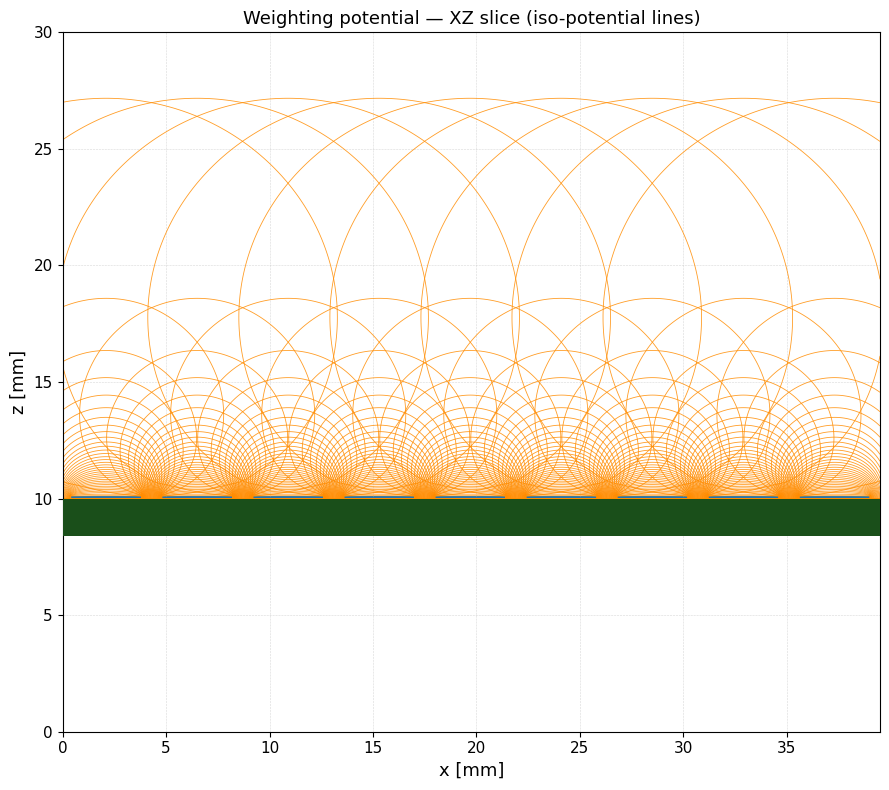

In [30]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))

# Iso-potential contours for each pixel
levels = np.linspace(0.01, 0.99, 35)
for phi_i in phi_per_pixel:
    ax.contour(
        x_mm, z_mm, phi_i.T,
        levels=levels,
        colors='darkorange',
        linewidths=0.6,
        alpha=0.85,
    )

# PCB slab: 3 mm thick, just below the pixel plane (z = 7..10 mm)
pcb_h_mm  = z_mm[iz_pixel]   # 10 mm — pixel plane
pcb_thick = 1.6               # mm
pcb_z_bot = pcb_h_mm - pcb_thick   # 7 mm
ax.add_patch(mpatches.Rectangle(
    (x_mm[0], pcb_z_bot), x_mm[-1] - x_mm[0], pcb_thick,
    linewidth=0, facecolor='#1a4f1a', zorder=3
))

# Pixel pads sitting on top of PCB (at z = 10 mm)
pad_draw_h = 0.1   # mm — exaggerated for visibility
for (xl, xr) in pixel_patches:
    ax.add_patch(mpatches.Rectangle(
        (xl, pcb_z_bot+pcb_thick), xr - xl, pad_draw_h,
        # linewidth=1.0, edgecolor='magenta', facecolor='#2e7d2e', zorder=4
    ))
    # ax.hlines(pcb_h_mm, xl, xr, colors='magenta', linewidths=1.2, zorder=5)

ax.set_xlim(x_mm[0], x_mm[-1])
ax.set_ylim(0, 30)   # zoom in on region near pixel plane
ax.set_xlabel('x [mm]', fontsize=13)
ax.set_ylabel('z [mm]', fontsize=13)
ax.set_title('Weighting potential — XZ slice (iso-potential lines)', fontsize=13)
ax.tick_params(labelsize=11)
ax.set_facecolor('white')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig('weighting_potential_fieldlines.png', dpi=150)
plt.show()

In [ ]:
## dRIFT field takes about 1 hour for 44x44x1500
## weighting field takes about 2.4 hours for 396x396x1500. The needs ~20GB gpu memory